# 3. Scoring real companies

The ML model wins in the lab, but it was trained on Polish firms. In this notebook I point it at live Indian companies, find exactly where it breaks (it can't judge numbers outside the range it learned on), and settle on the engine that actually holds up - the linear Altman score - while keeping the ML model as the benchmark that proved the method.

Then I add the part that makes this more than a ratio calculator: four **digital signals** that read the outside world.

## The four digital signals

Financial statements come out once a year. These four signals read what is happening in between, each scored on the same 0-100 scale as the financial score:

- **News sentiment** (FinBERT on recent headlines)
- **Leadership stability** (CFO/auditor/board exits from exchange filings)
- **Hiring trend** (are job postings shrinking?)
- **Employee confidence** (rating trend)

When the outside world looks worse than the last set of accounts, that gap is the early warning.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

NAVY, AMBER, GOOD, WATCH, ELEV, BAD = "#0A1628", "#F59E0B", "#22C55E", "#F59E0B", "#F97316", "#EF4444"
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25})

## 5. The cross-domain finding that reshaped the architecture

Here is the most important result in the project. The GBM is trained on Polish firms. When
we score a **real Indian company**, the learned decision boundary does **not** transfer -
tree models clamp out-of-range values instead of extrapolating, and missingness means
different things in the two domains.

Altman Z'' is **linear**, so it extrapolates, and it has no training distribution to carry
across borders. So the serving engine is Altman-anchored; the GBM is the methodology
showcase. We validate this on current companies.

In [11]:
from src.scoring import ROSTER, validate_roster
gate = pd.DataFrame(validate_roster())
print(gate.to_string(index=False))
print("\nEvery company lands in its expected band - on the linear Altman engine.")
assert gate["pass"].all()

      company  year expected  z_score  risk     band  pass
     SpiceJet  2026 distress    -5.84  99.4 Critical  True
 Ola Electric  2026 distress    -1.86  89.8 Critical  True
Vodafone Idea  2026 distress    -1.46  86.7 Critical  True
      Vedanta  2026    watch     1.18  48.5    Watch  True
        Paytm  2026  healthy     4.13   9.8  Healthy  True
          TCS  2026  healthy     6.93   1.4  Healthy  True

Every company lands in its expected band - on the linear Altman engine.


## 6. Live scores - six current companies

Financials fused with four live market signals (news sentiment via FinBERT, leadership
changes, hiring trend, employee sentiment). 60% financial / 40% digital, renormalised.

      company  combined  financial  digital          band
     SpiceJet      85.8       99.4     65.3      Critical
 Ola Electric      77.3       89.8     58.5      Critical
Vodafone Idea      71.2       86.7     47.9 Elevated Risk
      Vedanta      34.5       48.5     13.6         Watch
        Paytm      14.4        9.8     21.4       Healthy
          TCS      12.2        1.4     28.4       Healthy


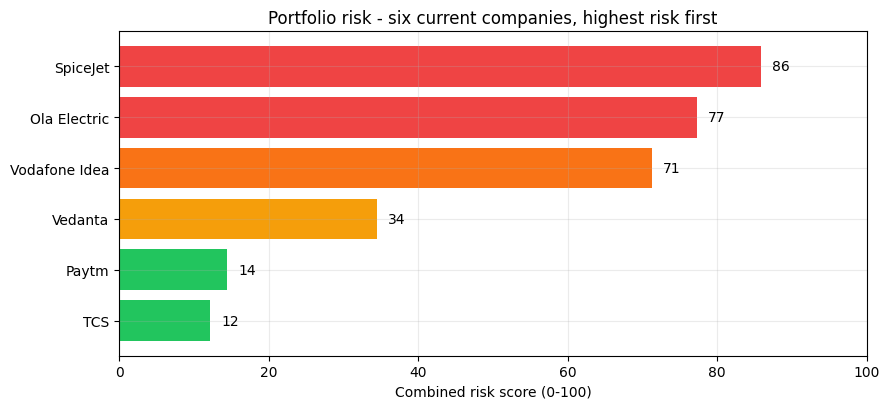

In [12]:
from src.scoring import score_company
from src.signals import pulse_as_of, DEFAULT_AS_OF
from src.signals import LoughranMcDonaldScorer
from src.scoring import fuse

scorer = LoughranMcDonaldScorer()  # deterministic for reproducibility
recs = []
for rec, prior, _ in ROSTER:
    fin = score_company(rec, prior=prior)
    dig = pulse_as_of(rec.company, DEFAULT_AS_OF[rec.company], scorer)
    c = fuse(fin, dig)
    recs.append((rec.company, c.combined_score, c.financial_score, c.digital_score, c.band))
port = pd.DataFrame(recs, columns=["company", "combined", "financial", "digital", "band"]).sort_values("combined", ascending=False)
print(port.to_string(index=False))

cmap = {"Healthy": GOOD, "Watch": WATCH, "Elevated Risk": ELEV, "Critical": BAD}
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(port["company"][::-1], port["combined"][::-1],
        color=[cmap[b] for b in port["band"][::-1]])
ax.set_xlabel("Combined risk score (0-100)"); ax.set_xlim(0, 100)
ax.set_title("Portfolio risk - six current companies, highest risk first")
for i, v in enumerate(port["combined"][::-1]):
    ax.text(v + 1.5, i, f"{v:.0f}", va="center", fontsize=10)
plt.tight_layout(); plt.show()

## 7. Explainability - in business language

The model's drivers, renamed from cryptic `AttrN` variables to what a credit analyst
reads. This is the global picture; the app shows a per-company Altman decomposition that
sums exactly to the displayed score.

                                Driver      Category  Mean impact
Operating Expenses / Total Liabilities    Efficiency      1.04858
               Interest Coverage Ratio      Solvency      0.73385
    3-Year Gross Profit / Total Assets Profitability      0.56188
           Sales Growth (year on year)        Growth      0.43336
                   Cost to Sales Ratio    Efficiency      0.43155
                     Cash Gross Margin Profitability      0.29348
       Company Size (log total assets)          Size      0.28101
                      Return on Assets Profitability      0.26981
      Retained Earnings / Total Assets Profitability      0.26905
       Operating Profit / Total Assets Profitability      0.20464
               Reserves / Total Assets      Solvency      0.19477
Debt to Annualised Operating Cash Flow      Solvency      0.18553


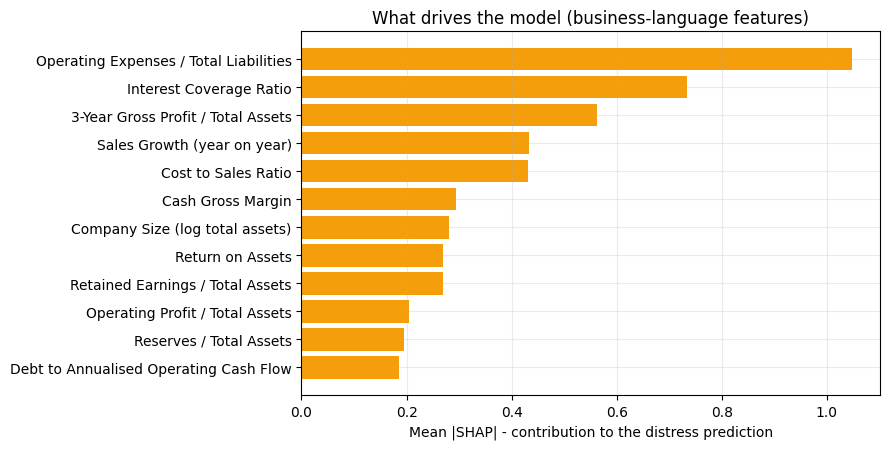

In [13]:
from src.model import fit_calibrated
import src.model as explain

est, rep, feats = fit_calibrated(df, feature_set="screener")
gi = explain.global_importance(est, df[feats], feats, top_n=12)
print(gi.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(gi["Driver"][::-1], gi["Mean impact"][::-1], color=AMBER)
ax.set_xlabel("Mean |SHAP| - contribution to the distress prediction")
ax.set_title("What drives the model (business-language features)")
plt.tight_layout(); plt.show()

---
### Summary

- Accuracy is meaningless at a 3.9% base rate; we evaluate on **PR-AUC** (0.80, 20x random).
- The model **beats the Altman benchmark ~11x on precision** at matched recall.
- We **dropped SMOTE** because the ablation said to.
- The GBM **does not transfer cross-border**, so serving is **Altman-anchored** - validated
  on six current companies, each in its expected band.
- Explainability is in **business language**, and the report/UI decomposition is exact.

Full rationale is in `docs/`.